In [1]:
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/GumbleRIS/RIS_Channels.mat'

Mounted at /content/drive


In [2]:
!pip install scipy

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import math
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
from scipy.io import loadmat

data = loadmat(DATA_PATH)

print(data.keys())
G_all = data['G']
H_all = data['H']
D_all = data['D']

print("Shapes:")
print("G:", G_all.shape)
print("H:", H_all.shape)
print("D:", D_all.shape)

dict_keys(['__header__', '__version__', '__globals__', 'H', 'G', 'D'])
Shapes:
G: (64, 256, 5000)
H: (256, 64, 5000)
D: (64, 64, 5000)


In [5]:
class RISDataset(Dataset):
    def __init__(self, G, H, D):
        self.G = G
        self.H = H
        self.D = D
        self.N = G.shape[2]   # 5000 samples

    def __len__(self):
        return self.N

    def __getitem__(self, idx):

        G = self.G[:, :, idx]      # (64,256)
        H = self.H[:, :, idx]      # (256,64)
        D = self.D[:, :, idx]      # (64,64)

        # normalization
        power = (
            np.mean(np.abs(G)**2) +
            np.mean(np.abs(H)**2) +
            np.mean(np.abs(D)**2)
        )
        scale = np.sqrt(power + 1e-12)

        G = G / scale
        H = H / scale
        D = D / scale

        # reshape for CNN
        H_pad = H.T                # (64,256)
        D_pad = np.zeros((64,256), dtype=np.complex128)
        D_pad[:, :64] = D

        tensor = np.stack([
            np.real(G),
            np.imag(G),
            np.real(H_pad),
            np.imag(H_pad),
            np.real(D_pad),
            np.imag(D_pad)
        ], axis=0)   # (6,64,256)

        return (
            torch.tensor(tensor, dtype=torch.float32),
            torch.tensor(G, dtype=torch.complex64),
            torch.tensor(H, dtype=torch.complex64),
            torch.tensor(D, dtype=torch.complex64)
        )


In [6]:
dataset = RISDataset(G_all, H_all, D_all)

N = len(dataset)
train_size = int(0.6 * N)
val_size = int(0.2 * N)
test_size = N - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=8)
test_loader  = DataLoader(test_set, batch_size=8)

print("Split done.")

Split done.


In [7]:
class GumbelRIS(nn.Module):
    def __init__(self, tau=1.0):
        super().__init__()
        self.tau = tau

        self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 256*4)

    def forward(self, x, hard=False):
        x = F.relu(self.conv(x))
        x = self.pool(x).view(x.size(0), -1)
        logits = self.fc(x)
        logits = logits.view(-1, 256, 4)

        y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
        return y, logits

In [8]:
theta = torch.tensor([0, math.pi/2, math.pi, 3*math.pi/2],
                     dtype=torch.float32, device=device)

def construct_phase(y):
    phi = torch.sum(y * theta, dim=2)
    return torch.exp(1j * phi)

In [9]:
def compute_capacity(G, H, D, phi, Pt=20.0, sigma2=1.0):
    batch = G.shape[0]
    capacities = []

    for b in range(batch):
        Phi = torch.diag(phi[b])

        C = G[b] @ Phi @ H[b] + D[b]

        Nr = C.shape[0]
        I = torch.eye(Nr, dtype=torch.complex64, device=device)

        M = I + (Pt/sigma2) * (C @ C.conj().T)

        # Use logdet safely
        sign, logdet = torch.linalg.slogdet(M)

        cap = logdet / torch.log(torch.tensor(2.0, device=device))
        capacities.append(cap.real)

    return torch.mean(torch.stack(capacities))

In [10]:
model = GumbelRIS(tau=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Total parameters:",
      sum(p.numel() for p in model.parameters()))

Total parameters: 35552


In [11]:
# Check average channel magnitude
print("Mean |G|:", np.mean(np.abs(G_all)))
print("Mean |H|:", np.mean(np.abs(H_all)))
print("Mean |D|:", np.mean(np.abs(D_all)))

Mean |G|: 0.0003923006243191256
Mean |H|: 5.8031316903819844e-05
Mean |D|: 6.805325141335878e-06


In [12]:
print("G shape:", G_all.shape)
print("H shape:", H_all.shape)
print("D shape:", D_all.shape)

G shape: (64, 256, 5000)
H shape: (256, 64, 5000)
D shape: (64, 64, 5000)


In [21]:
epochs = 20        # number of training epochs
tau0 = 1.0         # initial temperature
tau_min = 0.05     # minimum temperature
anneal_rate = 0.95 # annealing decay rate
train_losses = []

for epoch in range(epochs):
    model.train()
    model.tau = max(tau_min, tau0 * (anneal_rate ** epoch))

    total_loss = 0

    for x, G, H, D in tqdm(train_loader):
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x)
        phi = construct_phase(y)

        loss = -compute_capacity(G, H, D, phi)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Tau: {model.tau:.4f}")

100%|██████████| 375/375 [00:08<00:00, 43.58it/s]


Epoch 1 | Loss: -31.9693 | Tau: 1.0000


100%|██████████| 375/375 [00:08<00:00, 45.15it/s]


Epoch 2 | Loss: -55.1606 | Tau: 0.9500


100%|██████████| 375/375 [00:08<00:00, 46.68it/s]


...

Epoch 18 | Loss: -63.8165 | Tau: 0.4181


100%|██████████| 375/375 [00:08<00:00, 43.25it/s]


Epoch 19 | Loss: -63.5318 | Tau: 0.3972


100%|██████████| 375/375 [00:08<00:00, 43.08it/s]

Epoch 20 | Loss: -63.3495 | Tau: 0.3774


In [22]:
model.eval()
capacities = []

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x, hard=True)
        phi = construct_phase(y)

        cap = compute_capacity(G, H, D, phi)
        capacities.append(cap.item())

mean_cap = np.mean(capacities)
std_cap = np.std(capacities)

print("Mean Capacity:", mean_cap)
print("Std Dev:", std_cap)

Mean Capacity: 64.05304768371582
Std Dev: 20.442202587402278


In [23]:
import scipy.stats as stats

ci = stats.t.interval(
    0.95,
    len(capacities)-1,
    loc=mean_cap,
    scale=std_cap/np.sqrt(len(capacities))
)

print("95% CI:", ci)

95% CI: (np.float64(60.43411967906906), np.float64(67.67197568836256))


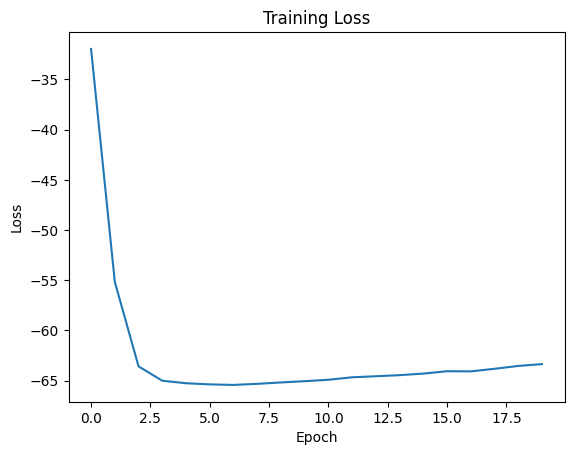

In [24]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [25]:
from collections import Counter

model.eval()
phase_counts = Counter()

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)

        y, _ = model(x, hard=True)
        phi = torch.sum(y * theta, dim=2)  # phase angles

        # Flatten batch
        phi_flat = phi.cpu().numpy().flatten()

        # Convert to discrete bins
        for val in phi_flat:
            if np.isclose(val, 0):
                phase_counts["0"] += 1
            elif np.isclose(val, np.pi/2):
                phase_counts["pi/2"] += 1
            elif np.isclose(val, np.pi):
                phase_counts["pi"] += 1
            elif np.isclose(val, 3*np.pi/2):
                phase_counts["3pi/2"] += 1

print("Learned 2-bit Phase Distribution:")
for k, v in phase_counts.items():
    print(f"{k}: {v}")

Learned 2-bit Phase Distribution:
0: 61207
pi/2: 64380
pi: 68577
3pi/2: 61836


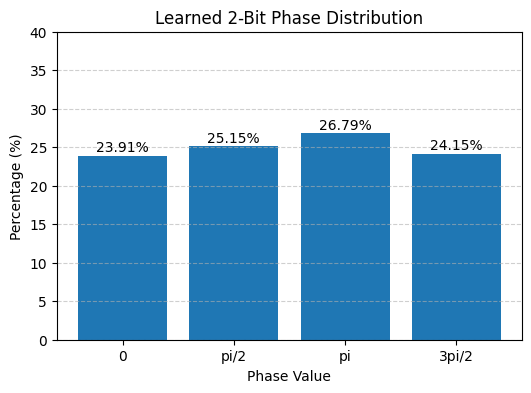

In [26]:
import matplotlib.pyplot as plt

# Convert to percentages
total = sum(phase_counts.values())

labels = list(phase_counts.keys())
percentages = [100 * phase_counts[k] / total for k in labels]

# -----------------------
# BAR PLOT
# -----------------------
plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Learned 2-Bit Phase Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Phase Value")

# Add value labels on bars
for i, v in enumerate(percentages):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# **Average Capacity vs Number of RIS elements**

In [ ]:
def evaluate_gumbel_ris(N_ris, epochs=10):
    """
    Train + evaluate GumbelRIS for given number of RIS elements.
    Returns mean capacity.
    """

    print(f"\n===== Training for N_RIS = {N_ris} =====")

    # Modify model output size dynamically
    class GumbelRIS_Dynamic(nn.Module):
        def __init__(self, tau=1.0):
            super().__init__()
            self.tau = tau
            self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(32, N_ris * 4)

        def forward(self, x, hard=False):
            x = F.relu(self.conv(x))
            x = self.pool(x).view(x.size(0), -1)
            logits = self.fc(x)
            logits = logits.view(-1, N_ris, 4)
            y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
            return y, logits

    model = GumbelRIS_Dynamic().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # -------- TRAIN --------
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, G, H, D in train_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)

            y, _ = model(x)
            phi = construct_phase(y)

            loss = -compute_capacity(G, H, D, phi)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss {total_loss/len(train_loader):.4f}")

    # -------- TEST --------
    model.eval()
    capacities = []

    with torch.no_grad():
        for x, G, H, D in test_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)

            y, _ = model(x, hard=True)
            phi = construct_phase(y)

            cap = compute_capacity(G, H, D, phi)
            capacities.append(cap.item())

    mean_cap = np.mean(capacities)
    print(f"Mean Capacity for N={N_ris}: {mean_cap:.4f}")

    return mean_cap

In [ ]:
RIS_sizes = [4, 16, 64, 256]
avg_capacities = []

for N_ris in RIS_sizes:
    cap = evaluate_gumbel_ris(N_ris, epochs=5)
    avg_capacities.append(cap)


===== Training for N_RIS = 4 =====


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x256 and 4x4)

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(RIS_sizes, avg_capacities, marker='o', linewidth=2)

plt.xscale('log', base=2)

plt.xlabel("Number of RIS Elements ($N_{RIS}$)")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("GumbelRIS: Capacity vs RIS Elements")
plt.grid(True)

plt.show()

# **Average Capacity vs Pt**

In [ ]:
SNR_dB_values = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
avg_capacities = []

In [ ]:
def evaluate_capacity_vs_snr(model, snr_db):

    model.eval()
    capacities = []

    snr_linear = 10 ** (snr_db / 10)

    with torch.no_grad():
        for x, G, H, D in test_loader:

            x = x.to(device)
            G = G.to(device)
            H = H.to(device)
            D = D.to(device)

            y, _ = model(x, hard=True)
            phi = construct_phase(y)

            cap = compute_capacity(
                G, H, D, phi,
                Pt=snr_linear,   # <-- control SNR here
                sigma2=1.0
            )

            capacities.append(cap.item())

    return np.mean(capacities)

In [ ]:
for snr_db in SNR_dB_values:
    print(f"Evaluating at SNR = {snr_db} dB")

    mean_cap = evaluate_capacity_vs_snr(model, snr_db)
    avg_capacities.append(mean_cap)

    print(f"Average Capacity: {mean_cap:.4f} bps/Hz\n")

Evaluating at SNR = 0 dB
Average Capacity: 14.5433 bps/Hz

Evaluating at SNR = 2 dB
Average Capacity: 15.6165 bps/Hz

Evaluating at SNR = 4 dB
Average Capacity: 16.7173 bps/Hz

Evaluating at SNR = 6 dB
Average Capacity: 17.7594 bps/Hz

Evaluating at SNR = 8 dB
Average Capacity: 19.1137 bps/Hz

Evaluating at SNR = 10 dB
Average Capacity: 20.6065 bps/Hz

Evaluating at SNR = 12 dB
Average Capacity: 22.2484 bps/Hz

Evaluating at SNR = 14 dB
Average Capacity: 24.1420 bps/Hz

Evaluating at SNR = 16 dB
Average Capacity: 26.1028 bps/Hz

Evaluating at SNR = 18 dB
Average Capacity: 28.2696 bps/Hz

Evaluating at SNR = 20 dB
Average Capacity: 30.3810 bps/Hz



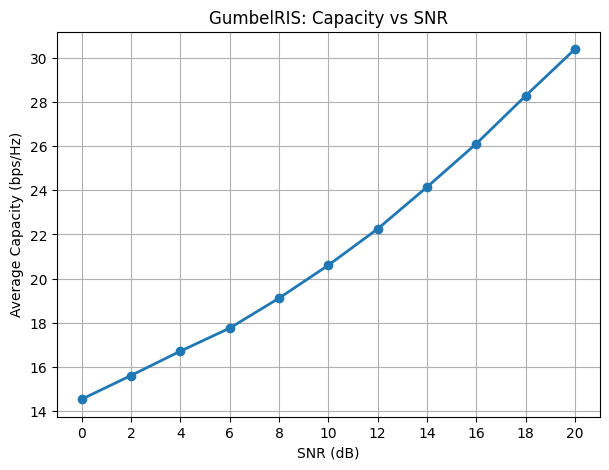

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(SNR_dB_values, avg_capacities,
         marker='o', linewidth=2)

plt.xlabel("SNR (dB)")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("GumbelRIS: Capacity vs SNR")
plt.grid(True)
plt.xticks(SNR_dB_values)

plt.show()

# **Average Capacity vs Softmax Temperature(Tau)**

In [13]:
tau_values = [0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 2.0, 5.0]
num_monte_carlo = 60
avg_capacities_tau = []

In [14]:
def train_model_for_tau(tau_init, epochs=10):

    model = GumbelRIS(tau=tau_init).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    tau_min = 0.05
    anneal_rate = 0.95

    for epoch in range(epochs):

        model.train()

        # temperature annealing
        model.tau = max(tau_min, tau_init * (anneal_rate ** epoch))

        for x, G, H, D in train_loader:

            x = x.to(device)
            G = G.to(device)
            H = H.to(device)
            D = D.to(device)

            y, _ = model(x)

            phi = construct_phase(y)

            loss = -compute_capacity(G, H, D, phi)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [15]:
def evaluate_capacity(model):

    model.eval()

    capacities = []

    with torch.no_grad():

        for mc in range(num_monte_carlo):

            for x, G, H, D in test_loader:

                x = x.to(device)
                G = G.to(device)
                H = H.to(device)
                D = D.to(device)

                # discrete inference
                y, _ = model(x, hard=True)

                phi = construct_phase(y)

                cap = compute_capacity(G, H, D, phi)

                capacities.append(cap.item())

    return np.mean(capacities)

In [16]:
for tau in tau_values:

    print(f"\nTraining model for τ = {tau}")

    model_tau = train_model_for_tau(tau)

    print("Evaluating...")

    mean_cap = evaluate_capacity(model_tau)

    avg_capacities_tau.append(mean_cap)

    print(f"Average Capacity = {mean_cap:.4f}")


Training model for τ = 0.05
Evaluating...
Average Capacity = 61.4443

Training model for τ = 0.1
Evaluating...
Average Capacity = 61.7546

Training model for τ = 0.3
Evaluating...
Average Capacity = 63.9461

Training model for τ = 0.5
Evaluating...
Average Capacity = 64.1481

Training model for τ = 0.7
Evaluating...
Average Capacity = 63.8293

Training model for τ = 1.0
Evaluating...
Average Capacity = 63.2118

Training model for τ = 2.0
Evaluating...
Average Capacity = 62.5808

Training model for τ = 5.0
Evaluating...
Average Capacity = 63.9701


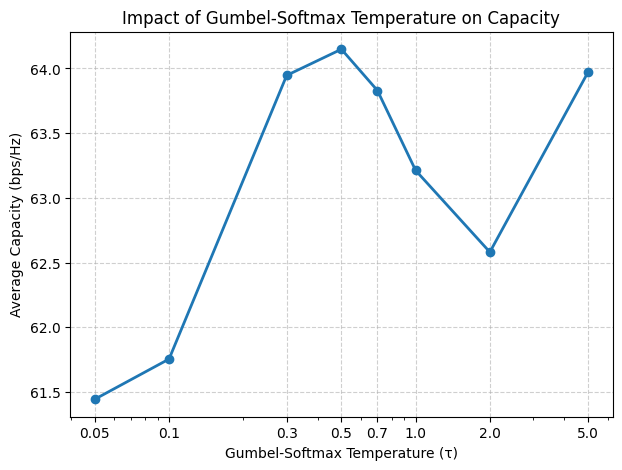

In [20]:
plt.figure(figsize=(7,5))

plt.plot(tau_values,
         avg_capacities_tau,
         marker='o',
         linewidth=2)

plt.xscale('log')

plt.xlabel("Gumbel-Softmax Temperature (τ)")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("Impact of Gumbel-Softmax Temperature on Capacity")

plt.xticks(tau_values, tau_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()